# 1. Loading & prep

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os
import sys
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.ensemble import RandomForestRegressor


In [2]:
sys.path.append('..')  # points to the Modelling/ folder

from gam import SklearnGAM

sys.path.append('../..')  # points to the code folder
sys.path.append('/data/cleaning-scripts/')
from config import INCLUDE_VOYAGE_DUMMIES, WINDOW_LENGTH, JANUARY_CLEANING_DATE, JULY_CLEANING_DATE, FOULING_PROXY_VAR_NAME_WITH_UNIT, SPEED_VARIABLE, WEATHER_FEATURES, NON_WEATHER_FEATURES, CANDIDATE_FEATURES, TARGET_VARIABLE

In [3]:
notebook_dir = os.getcwd()
notebook_parent_dir = os.path.dirname(notebook_dir)
notebook_parent_parent_dir = os.path.dirname(notebook_parent_dir)
engineered_data_path = os.path.join(notebook_parent_parent_dir, 'data', 'engineered', f'engineered_features_{WINDOW_LENGTH}.csv')

In [4]:
df = pd.read_csv(engineered_data_path)
df["window_start"] = pd.to_datetime(df["window_start"], format='ISO8601', utc=True)

In [5]:
df.columns

Index(['seg_id', 'window_start', 'Vessel Hull Over Ground Speed (knots)',
       'Vessel Hull Through Water Longitudinal Speed (knots)',
       'Vessel External Conditions Wind Relative Speed (knots)',
       'Vessel External Conditions Wind Relative Angle (degrees)',
       'Vessel Hull Heading True Angle (degrees)',
       'Vessel Hull Heading Turn Rate (deg/min)',
       'Main Engine Turbocharger Rotational Speed (rpm)',
       'Main Engine Scavenging Air Pressure (bar)',
       'Main Engine Fuel Load % (%)', 'Main Engine Rotational Speed (rpm)',
       'Vessel Propeller Shaft Torque (N*m)',
       'Vessel Propeller Shaft Mechanical Power (KW)',
       'Main Engine Fuel Oil Inlet Mass Flow (kg/hr)',
       'Vessel Propeller Shaft Mechanical Energy (KWh)',
       'Vessel Propeller Shaft Thrust Force (KN)',
       'Vessel Propeller Shaft Rotational Speed (rpm)',
       'Vessel Propeller Shaft Revolutions (cumulative) (revs)',
       'Sea Temperature Dropout', 'Calculated Shaft Power',

# 2. Correlations / VIFs

## 2.1. Correlations

['Vessel External Conditions Sea Water Temperature (Provider S)',
 'SOG - STW (calculated)',
 'Vessel External Conditions Wave Period (Provider S)',
 'longitudinal_wind_force (calculated)',
 'longitudinal_wave_force (calculated)',
 'longitudinal_swell_force (calculated)',
 'transversal_wind_force (calculated)',
 'transversal_wave_force (calculated)',
 'transversal_swell_force (calculated)',
 'Avg Draft (Calculated)',
 'Draft Trim (Calculated)',
 'Days Since Last Cleaning',
 'Vessel Hull Through Water Longitudinal Speed (knots)']

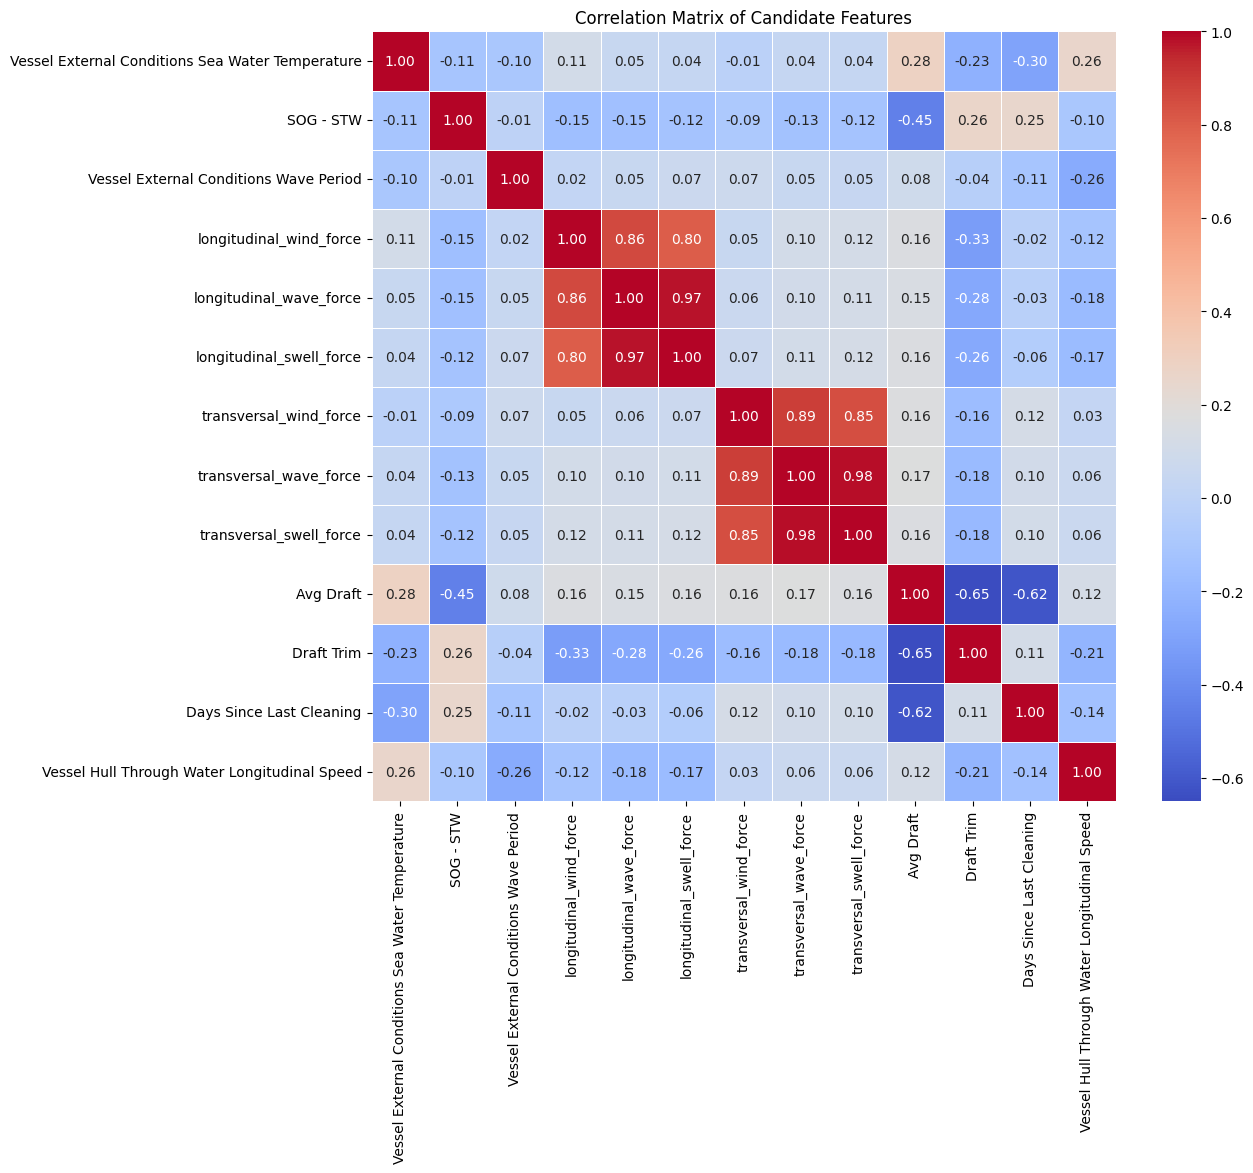

In [6]:
candidate_features = CANDIDATE_FEATURES.copy()

if INCLUDE_VOYAGE_DUMMIES:
    candidate_features = candidate_features + [col for col in df.columns if col.startswith("voyage_")]

display(candidate_features)

# make a correlation matrix between all the candidate features. Before plotting, remove everything inside parenthesis from the column names for better readability
correlation_df = df[CANDIDATE_FEATURES].copy()
correlation_df.columns = [col.split(' (')[0] for col in correlation_df.columns]
correlation_matrix = correlation_df.corr()

# plot the correlation matrix as a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Candidate Features')
plt.show()

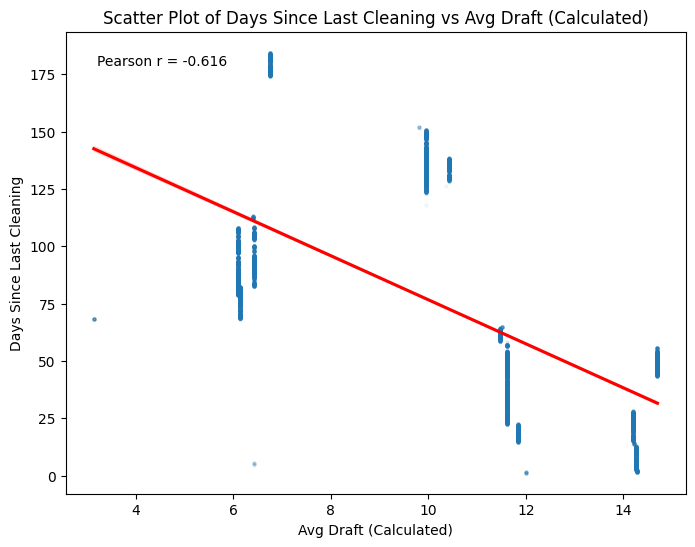

In [7]:
x = 'Avg Draft (Calculated)'
y = FOULING_PROXY_VAR_NAME_WITH_UNIT

plot_df = df[[x, y]].dropna()
corr = plot_df[x].corr(plot_df[y])

plt.figure(figsize=(8, 6))
sns.regplot(
    x=x,
    y=y,
    data=plot_df,
    scatter_kws={'alpha': 0.05, 's': 5},
    line_kws={'color': 'red'}
)
plt.title(f'Scatter Plot of {y} vs {x}')
plt.xlabel(x)
plt.ylabel(y)
plt.text(
    0.05, 0.95,
    f'Pearson r = {corr:.3f}',
    transform=plt.gca().transAxes,
    ha='left', va='top',
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')
)
plt.show()


## 2.2. VIFs

In [8]:
# Based on the candidate feautures, compute all the VIF scores and sort them from highest to lowest. Print it for all the features in a readable format.
def compute_vif(df: pd.DataFrame, candidate_features: list) -> pd.DataFrame:
    """
    Compute VIF for all candidate features and return sorted DataFrame.
    Drops rows with any NaN in the candidate columns before computing.
    """
    X = df[candidate_features].dropna()
    
    vif_data = pd.DataFrame({
        "Feature": candidate_features,
        "VIF": [variance_inflation_factor(X.values, i) 
                for i in range(len(candidate_features))]
    })
    
    return vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)

# Usage
vif_results = compute_vif(df, CANDIDATE_FEATURES)
print(vif_results.to_string(index=False))

                                                      Feature       VIF
         Vessel Hull Through Water Longitudinal Speed (knots) 82.486788
                          transversal_wave_force (calculated) 43.261668
Vessel External Conditions Sea Water Temperature (Provider S) 41.214349
                         longitudinal_wave_force (calculated) 34.731622
                                       Avg Draft (Calculated) 32.380215
                         transversal_swell_force (calculated) 31.104704
                        longitudinal_swell_force (calculated) 24.518101
          Vessel External Conditions Wave Period (Provider S)  6.726600
                          transversal_wind_force (calculated)  5.787034
                                     Days Since Last Cleaning  5.711662
                         longitudinal_wind_force (calculated)  5.246602
                                      Draft Trim (Calculated)  4.666570
                                       SOG - STW (calculated)  1

## 2.3. Corr and VIF-based selection

### 2.3.1. First removal

In [ ]:
vars_to_remove = [
    'Vessel External Conditions Sea Water Temperature (Provider S)',
    'Vessel External Conditions Wave Period (Provider S)',
    "Avg Draft (Calculated)",
#    'Draft Trim (Calculated)',
#     'SOG - STW (calculated)',
]

second_it_candidate_features = [feature for feature in CANDIDATE_FEATURES if feature not in vars_to_remove] 

df_2 = df[second_it_candidate_features]

In [10]:
second_it_candidate_features

['SOG - STW (calculated)',
 'longitudinal_wind_force (calculated)',
 'longitudinal_wave_force (calculated)',
 'longitudinal_swell_force (calculated)',
 'transversal_wind_force (calculated)',
 'transversal_wave_force (calculated)',
 'transversal_swell_force (calculated)',
 'Avg Draft (Calculated)',
 'Draft Trim (Calculated)',
 'Days Since Last Cleaning',
 'Vessel Hull Through Water Longitudinal Speed (knots)']

### 2.3.2. Second check

In [11]:
vif__second_it_results = compute_vif(df_2, second_it_candidate_features)
print(vif__second_it_results.to_string(index=False))

                                             Feature       VIF
Vessel Hull Through Water Longitudinal Speed (knots) 53.173189
                 transversal_wave_force (calculated) 43.143990
                longitudinal_wave_force (calculated) 34.546479
                transversal_swell_force (calculated) 31.088738
                              Avg Draft (Calculated) 29.241611
               longitudinal_swell_force (calculated) 24.317765
                 transversal_wind_force (calculated)  5.742219
                            Days Since Last Cleaning  5.548016
                longitudinal_wind_force (calculated)  5.213917
                             Draft Trim (Calculated)  4.374148
                              SOG - STW (calculated)  1.869909


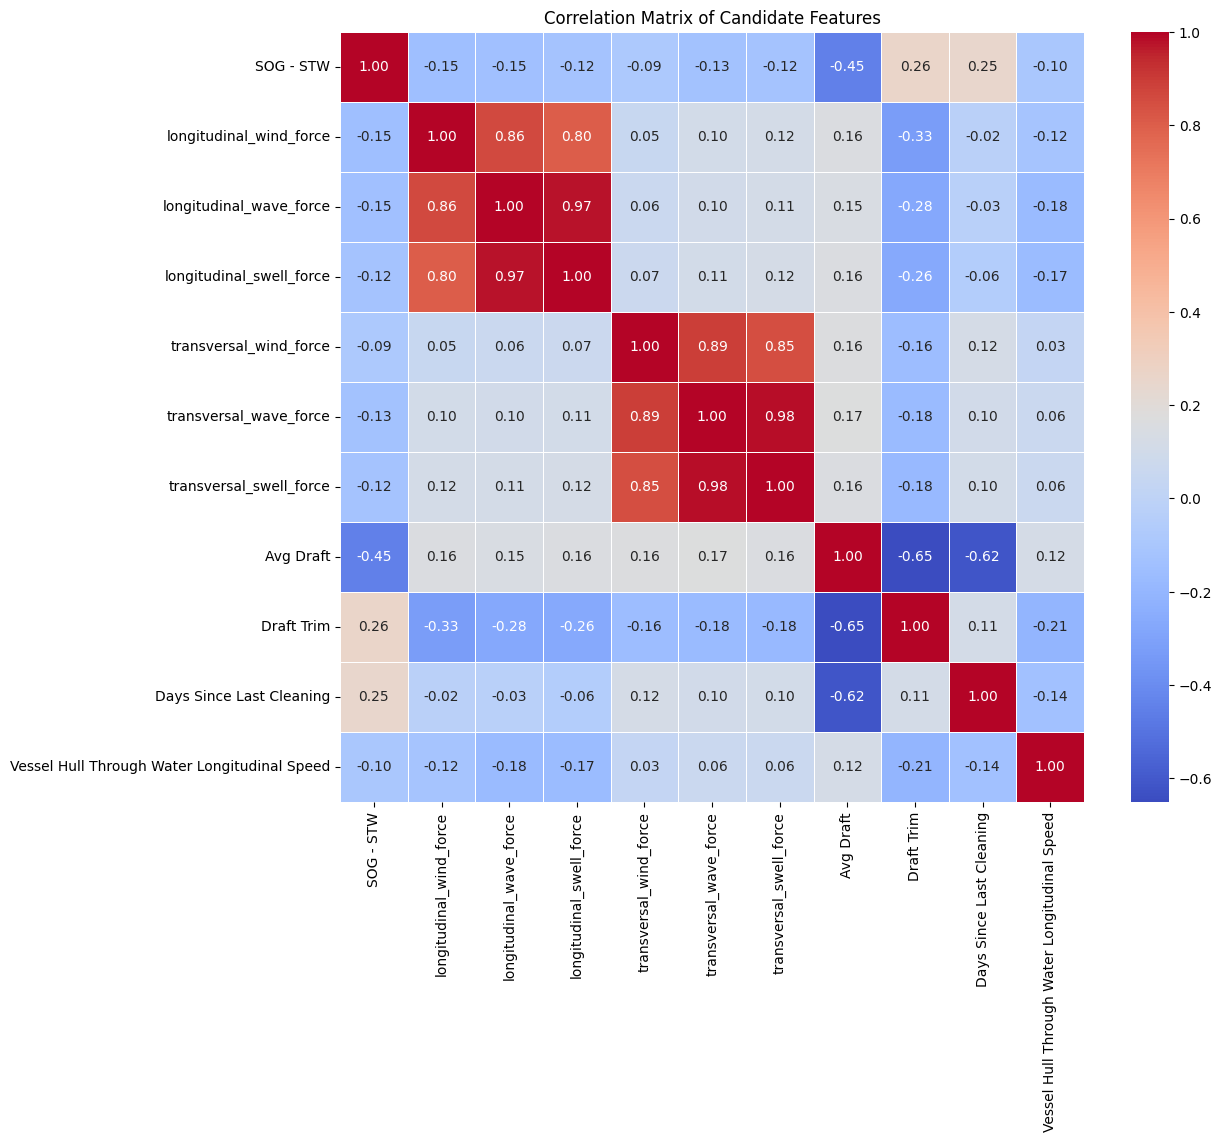

In [12]:
# make a correlation matrix between all the candidate features again. Before plotting, remove everything inside parenthesis from the column names for better readability
correlation_df = df_2[second_it_candidate_features].copy()
correlation_df.columns = [col.split(' (')[0] for col in correlation_df.columns]
correlation_matrix = correlation_df.corr()

# plot the correlation matrix as a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Candidate Features')
plt.show()